### Human in the loop

Human-in-the-Loop is a design pattern where AI systems involve humans in decision-making for low-confidence or high-risk cases, ensuring accuracy, safety, and continuous learning

In [81]:
from typing import Annotated
import operator,json
from typing import TypedDict, Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,END,START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
import os
from langchain_groq import ChatGroq

In [82]:
llm=ChatGroq(model="llama-3.1-8b-instant")

In [83]:
## Multiply Tool
@tool
def multiply(firstNumber:int,secondNumber:int)->int:
    """Multiply two number"""
    return firstNumber*secondNumber

In [84]:
multiply.invoke({"firstNumber":1,"secondNumber":2})

2

In [85]:
## Search Tool
@tool
def search(query:str):
    """perform the web search for the query"""
    tavily=TavilySearchResults()
    result=tavily.invoke(query)
    return result

In [86]:
tools=[multiply,search]

In [87]:
model_with_tools=llm.bind_tools(tools)

In [88]:
class AgentClass(TypedDict):
    messages:Annotated[Sequence[BaseMessage],operator.add]

In [89]:
## invoke model node
def invoke_model(state:AgentClass):
    messages=state["messages"]
    question=messages[-1]
    return {"messages":[model_with_tools.invoke(question)]}

In [90]:
response=model_with_tools.invoke("who is current president of USA, use search tool")

In [91]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7srhztn2d', 'function': {'arguments': '{"query":"current president of USA"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 277, 'total_tokens': 293, 'completion_time': 0.018974588, 'completion_tokens_details': None, 'prompt_time': 0.016826743, 'prompt_tokens_details': None, 'queue_time': 0.051306566, 'total_time': 0.035801331}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df6cd-394d-7d71-9abb-45c19dea5440-0', tool_calls=[{'name': 'search', 'args': {'query': 'current president of USA'}, 'id': '7srhztn2d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 277, 'output_tokens': 16, 'total_tokens': 293})

In [92]:
tool_details=response.additional_kwargs.get("tool_calls")[0]

In [93]:
tool_details

{'id': '7srhztn2d',
 'function': {'arguments': '{"query":"current president of USA"}',
  'name': 'search'},
 'type': 'function'}

In [94]:
tool_mapping={tool.name: tool for tool in tools}

In [95]:
tool_mapping

{'multiply': StructuredTool(name='multiply', description='Multiply two number', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x1582dc860>),
 'search': StructuredTool(name='search', description='perform the web search for the query', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x1582de0c0>)}

In [96]:
tool_mapping[response.additional_kwargs.get("tool_calls")[0].get("function").get("name")].invoke(json.loads(response.additional_kwargs.get("tool_calls")[0].get("function").get("arguments")))

[{'title': 'Presidents, vice presidents, and first ladies | USAGov',
  'url': 'https://www.usa.gov/presidents',
  'content': "### Current president\n\nThe 47th and current president of the United States is Donald John Trump. He was sworn into office on January 20, 2025.\n\n### Former U.S. presidents\n\nThe United States has had 45 former U.S. presidents. Read about past presidents and vice presidents.\n\nMany former presidents have presidential libraries and museums you can visit to learn about their lives and their time in office. Find presidential libraries and museums.\n\n### Requirements to be eligible to become president\n\nAccording to Article II of the U.S. Constitution, the president must:\n\nLearn about the U.S. presidential election process.\n\n## Vice president of the United States [...] ## Vice president of the United States\n\nThe vice president of the United States presides over the U.S. Senate and takes over the role of president of the United States if the president is 

In [97]:
## invoke tool node

def invoke_tool(state:AgentClass):
    tool_details=state["messages"][-1].additional_kwargs.get("tool_calls",[])[0]

    if tool_details is None:
        raise Exception("No tool calls found")
    
    print(f'Selected tool: {tool_details.get("function").get("name")}')

    if tool_details.get("function").get("name")=="search":
        ## Human intervention
        response = input(prompt=f"[y/n] continue with expensive web search?")
        
        if response=="n":
            raise Exception("Web search discard")
    
    response = tool_mapping[tool_details['function']['name']].invoke(json.loads(tool_details.get("function").get("arguments")))

    return {"messages":[response]}

In [98]:
## router node

def router(state:AgentClass):
    tool_calls = state['messages'][-1].additional_kwargs.get("tool_calls", [])

    if len(tool_calls):
        return "tool"
    else:
        return "end"

In [99]:
## making workflow

workflow=StateGraph(AgentClass)
workflow.add_edge(START,"ai_assistant")
workflow.add_node("ai_assistant",invoke_model)
workflow.add_node("tool",invoke_tool)

workflow.add_conditional_edges("ai_assistant",router,{"tool":"tool","end":END})


workflow.add_edge("tool",END)

In [100]:
app=workflow.compile()

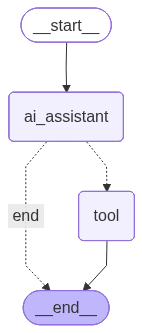

In [101]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [103]:
app.invoke({"messages":["Who is USA president"]})

Selected tool: search


{'messages': ['Who is USA president',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '959aavks0', 'function': {'arguments': '{"query":"USA president"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 271, 'total_tokens': 302, 'completion_time': 0.072473965, 'completion_tokens_details': None, 'prompt_time': 0.015918412, 'prompt_tokens_details': None, 'queue_time': 0.051313174, 'total_time': 0.088392377}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df6cd-8eea-7ca2-abf5-290c05a2b23a-0', tool_calls=[{'name': 'search', 'args': {'query': 'USA president'}, 'id': '959aavks0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 271, 'output_tokens': 31, 'total_tokens': 302}),
  [{'title': 'Presidents, vice presidents, and first la

In [104]:
## langgraph has inbuilt functionality of interrupt-before to keep human intervention in the loop

In [105]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [106]:
tavily=TavilySearchResults()

In [107]:
tools=[tavily]

In [108]:
llm_with_tools=llm.bind_tools(tools)

In [109]:
def ai_assistant(state:AgentState):
    return {"messages":[llm_with_tools.invoke(state["messages"][-1])]}

In [110]:
toolNode=ToolNode(tools)

In [111]:
memory=MemorySaver()

In [112]:
## Building workflow

graph=StateGraph(AgentState)

graph.add_node("ai_assistant",ai_assistant)
graph.add_node("tools",toolNode)
graph.add_conditional_edges("ai_assistant",tools_condition)
graph.add_edge(START,"ai_assistant")
graph.add_edge("tools","ai_assistant")

In [113]:
app2=graph.compile(
    checkpointer=memory,
    # this will interrupt the workflow so that a human intervention is created
    interrupt_before=["tools"]
)

In [114]:
app.invoke({"messages":["Who is USA president"]})


Selected tool: search


{'messages': ['Who is USA president',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ayxatqpxg', 'function': {'arguments': '{"query":"USA president"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 271, 'total_tokens': 285, 'completion_time': 0.059282694, 'completion_tokens_details': None, 'prompt_time': 0.019913718, 'prompt_tokens_details': None, 'queue_time': 0.051950223, 'total_time': 0.079196412}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df6d5-02cc-7452-9a44-a8b5e9b8761e-0', tool_calls=[{'name': 'search', 'args': {'query': 'USA president'}, 'id': 'ayxatqpxg', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 271, 'output_tokens': 14, 'total_tokens': 285}),
  [{'title': 'Presidents, vice presidents, and first la

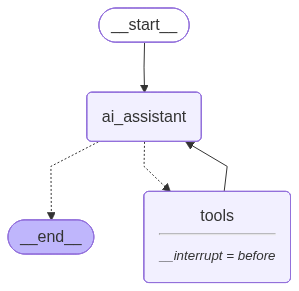

In [115]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))